Hybrid model that actually learn physics and use the history also 
we changed the target to delta_Target

In [71]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

from ipywidgets import interact, SelectMultiple

In [72]:


os.makedirs("comparison/results", exist_ok=True)
os.makedirs("comparison/feature_importance", exist_ok=True)
os.makedirs("comparison/graphs", exist_ok=True)

In [73]:
df = pd.read_csv("data/FINAL_DATASET_PREDICTION_CEjour.csv")

# ⚠️ garder si tu veux (mais pas optimal)
df.dropna(inplace=True)

print(df.shape)


(485151, 33)


In [74]:
# ==============================
# PHYSICS FEATURES V3 (NO LEAKAGE)
# ==============================

# --------------------------------
# BASIC PHYSICS
# --------------------------------

# pressure differential
df["DELTA_P"] = df["WHP"] - df["WHT"]

# --------------------------------
# FLOW EFFICIENCY (PAST ONLY)
# --------------------------------

df["FLOW_EFFICIENCY"] = (
    df["W_GAS"] /
    (df["WHP"] + 1e-6)
)

# ONLY PAST
df["FLOW_EFFICIENCY_LAG_1"] = (
    df.groupby("WELL")["FLOW_EFFICIENCY"]
    .shift(1)
)

# --------------------------------
# PRODUCTIVITY INDEX
# --------------------------------

df["PI"] = (
    df["W_GAS"] /
    (df["WHP"] + 1e-6)
)

df["PI_LAG_1"] = (
    df.groupby("WELL")["PI"]
    .shift(1)
)

# --------------------------------
# GAS LIQUID RATIO
# --------------------------------

df["GLR"] = (
    df["W_GAS"] /
    (df["WATER"] + df["COND_VOL"] + 1e-6)
)

df["GLR_LAG_1"] = (
    df.groupby("WELL")["GLR"]
    .shift(1)
)

# --------------------------------
# WATER CUT
# --------------------------------

df["WC"] = (
    df["WATER"] /
    (df["WATER"] + df["COND_VOL"] + 1e-6)
)

df["WC_LAG_1"] = (
    df.groupby("WELL")["WC"]
    .shift(1)
)

# --------------------------------
# ENERGY PROXY
# SAFE → uses current sensors only
# --------------------------------

df["ENERGY_PROXY"] = (
    (df["WHT"] + 273.15) /
    (df["WHP"] + 1)
)

# --------------------------------
# DYNAMIC FEATURES (PAST ONLY)
# --------------------------------

# pressure variation
df["DELTA_WHP"] = (
    df.groupby("WELL")["WHP"]
    .diff()
)

# temperature variation
df["DELTA_WHT"] = (
    df.groupby("WELL")["WHT"]
    .diff()
)

# production decline
df["GAS_DECLINE"] = (
    df.groupby("WELL")["W_GAS"]
    .diff()
)

# ONLY PAST
df["GAS_DECLINE_LAG_1"] = (
    df.groupby("WELL")["GAS_DECLINE"]
    .shift(1)
)

# production acceleration
df["GAS_ACCELERATION"] = (
    df.groupby("WELL")["W_GAS"]
    .diff()
    .diff()
)

# ONLY PAST
df["GAS_ACCELERATION_LAG_1"] = (
    df.groupby("WELL")["GAS_ACCELERATION"]
    .shift(1)
)

# --------------------------------
# TARGET DELTAS
# --------------------------------

df["TARGET_GAS_DELTA"] = (
    df.groupby("WELL")["W_GAS"]
    .diff()
)

df["TARGET_WATER_DELTA"] = (
    df.groupby("WELL")["WATER"]
    .diff()
)

df["TARGET_COND_DELTA"] = (
    df.groupby("WELL")["COND_VOL"]
    .diff()
)

# --------------------------------
# REMOVE LEAKY FEATURES
# --------------------------------

drop_leaky = [

    "FLOW_EFFICIENCY",
    "PI",
    "GLR",
    "WC",
    "GAS_DECLINE",
    "GAS_ACCELERATION"
]

df.drop(columns=drop_leaky, inplace=True)

# --------------------------------
# CLEANING
# --------------------------------

df = df.replace([np.inf, -np.inf], np.nan)

df.dropna(inplace=True)

print("Shape after physics engineering:", df.shape)

Shape after physics engineering: (484884, 46)


In [75]:
wellnames = df["WELL"].dropna().unique().tolist()

np.random.seed(42)
np.random.shuffle(wellnames)

train_wells = wellnames[:80]
blind_wells = wellnames[80:89]

print("Train wells:", len(train_wells))
print("Blind wells:", len(blind_wells))

#sauvegarde 
with open("split.json", "w") as f:
    json.dump({"train": train_wells, "blind": blind_wells}, f)

Train wells: 80
Blind wells: 9


In [76]:
features = [

    # RAW
    "WHP",
    "WHT",

    # LAGS
    "WHP_LAG_1",
    "WHP_LAG_3",
    "WHP_LAG_7",

    "WHT_LAG_1",
    "WHT_LAG_3",
    "WHT_LAG_7",

    "GAS_LAG_1",
    "GAS_LAG_3",
    "GAS_LAG_7",

    "WATER_LAG_1",
    "WATER_LAG_3",
    "WATER_LAG_7",

    "COND_LAG_1",
    "COND_LAG_3",
    "COND_LAG_7",

    # ROLLING
    "W_GAS_MEAN_3",
    "W_GAS_MEAN_7",

    "WATER_MEAN_3",
    "WATER_MEAN_7",

    "COND_VOL_MEAN_3",
    "COND_VOL_MEAN_7",

    # PHYSICS
    "DELTA_P",
    "FLOW_EFFICIENCY_LAG_1",
    "PI_LAG_1",
    "GLR_LAG_1",
    "WC_LAG_1",
    "GAS_DECLINE_LAG_1",
    "GAS_ACCELERATION_LAG_1",

    # TIME
    "DAY",
    "MONTH",
    "DAY_OF_WEEK"
]
targets = [
    "TARGET_GAS_DELTA",
    "TARGET_WATER_DELTA",
    "TARGET_COND_DELTA"
]

In [77]:
# ==============================
# TRAIN / TEST SPLIT (NO LEAKAGE)
# ==============================

train_list = []
test_list = []

for well in train_wells:

    df_w = df[df["WELL"] == well].sort_values("DATE")

    split_index = int(len(df_w) * 0.8)

    train_list.append(df_w.iloc[:split_index])
    test_list.append(df_w.iloc[split_index:])

train_df = pd.concat(train_list)
test_df  = pd.concat(test_list)

# FINAL MATRICES
X_train = train_df[features]
y_train = train_df[targets]

X_test  = test_df[features]
y_test  = test_df[targets]

# BLIND stays untouched
df_blind = df[df["WELL"].isin(blind_wells)].copy()
X_blind = df_blind[features]
y_blind = df_blind[targets]
# real targets for reconstruction evaluation
real_targets = ["W_GAS", "WATER", "COND_VOL"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Blind shape:", X_blind.shape)

Train shape: (353573, 33)
Test shape : (88431, 33)
Blind shape: (42880, 33)


In [78]:
# ==============================
# RECONSTRUCT ABSOLUTE VALUES
# ==============================

def reconstruct_absolute_values(X_base, y_pred_delta):

    # sécurité numpy
    y_pred_delta = np.array(y_pred_delta)

    # sécurité dimension
    if y_pred_delta.ndim == 1:
        y_pred_delta = y_pred_delta.reshape(-1, 3)

    # reconstruction
    pred_gas = (
        X_base["GAS_LAG_1"].values +
        y_pred_delta[:, 0]
    )

    pred_water = (
        X_base["WATER_LAG_1"].values +
        y_pred_delta[:, 1]
    )

    pred_cond = (
        X_base["COND_LAG_1"].values +
        y_pred_delta[:, 2]
    )

    # dataframe final
    result = pd.DataFrame({

        "W_GAS": pred_gas,
        "WATER": pred_water,
        "COND_VOL": pred_cond

    }, index=X_base.index)

    return result

In [79]:
# ==============================
# MODEL TRAINING FUNCTION
# ==============================

def run_model(name, model):

    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # ==========================
    # TRAIN
    # ==========================

    pipe.fit(X_train, y_train)

    # ==========================
    # DELTA PREDICTIONS
    # ==========================

    y_train_pred_delta = pipe.predict(X_train)
    y_test_pred_delta  = pipe.predict(X_test)
    y_blind_pred_delta = pipe.predict(X_blind)

    # ==========================
    # RECONSTRUCT ABSOLUTE VALUES
    # ==========================

    y_train_pred_abs = reconstruct_absolute_values(
        X_train,
        y_train_pred_delta
    )

    y_test_pred_abs = reconstruct_absolute_values(
        X_test,
        y_test_pred_delta
    )

    y_blind_pred_abs = reconstruct_absolute_values(
        X_blind,
        y_blind_pred_delta
    )

    # ==========================
    # EVALUATION
    # ==========================

    real_targets = ["W_GAS", "WATER", "COND_VOL"]

    for target in real_targets:

        print(f"\n----- {target} -----")

        train_r2 = r2_score(
            train_df[target],
            y_train_pred_abs[target]
        )

        test_r2 = r2_score(
            test_df[target],
            y_test_pred_abs[target]
        )

        blind_r2 = r2_score(
            df_blind[target],
            y_blind_pred_abs[target]
        )

        print("Train R2 :", round(train_r2, 4))
        print("Test  R2 :", round(test_r2, 4))
        print("Blind R2 :", round(blind_r2, 4))

    # ==========================
    # SAVE MODEL
    # ==========================

    os.makedirs("models", exist_ok=True)

    joblib.dump(
        pipe,
        f"models/{name}_DELTA.pkl"
    )

    return (
        pipe,

        y_train_pred_delta,
        y_test_pred_delta,
        y_blind_pred_delta,

        y_train_pred_abs,
        y_test_pred_abs,
        y_blind_pred_abs
    )

In [80]:
# ==============================
# LINEAR REGRESSION
# ==============================

(
    lr_model,

    y_train_lr_delta,
    y_test_lr_delta,
    y_blind_lr_delta,

    y_train_lr_abs,
    y_test_lr_abs,
    y_blind_lr_abs

) = run_model(
    "LinearRegression",
    LinearRegression()
)


===== LinearRegression =====

----- W_GAS -----
Train R2 : 0.95
Test  R2 : 0.9428
Blind R2 : 0.9409

----- WATER -----
Train R2 : 0.9732
Test  R2 : 0.9754
Blind R2 : 0.9049

----- COND_VOL -----
Train R2 : 0.9609
Test  R2 : 0.931
Blind R2 : 0.9599


In [81]:
# ==============================
# RANDOM FOREST
# ==============================

(
    rf_model,

    y_train_rf_delta,
    y_test_rf_delta,
    y_blind_rf_delta,

    y_train_rf_abs,
    y_test_rf_abs,
    y_blind_rf_abs

) = run_model(
    "RandomForest",
    RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
)


===== RandomForest =====

----- W_GAS -----
Train R2 : 0.9602
Test  R2 : 0.9566
Blind R2 : 0.9468

----- WATER -----
Train R2 : 0.973
Test  R2 : 0.9733
Blind R2 : 0.8838

----- COND_VOL -----
Train R2 : 0.9707
Test  R2 : 0.9565
Blind R2 : 0.9653


In [82]:
# ==============================
# DECISION TREE
# ==============================

(
    dt_model,

    y_train_dt_delta,
    y_test_dt_delta,
    y_blind_dt_delta,

    y_train_dt_abs,
    y_test_dt_abs,
    y_blind_dt_abs

) = run_model(
    "DecisionTree",
    DecisionTreeRegressor(
        max_depth=10
    )
)


===== DecisionTree =====

----- W_GAS -----
Train R2 : 0.9584
Test  R2 : 0.9508
Blind R2 : 0.9416

----- WATER -----
Train R2 : 0.9712
Test  R2 : 0.9722
Blind R2 : 0.8812

----- COND_VOL -----
Train R2 : 0.9692
Test  R2 : 0.95
Blind R2 : 0.9607


In [83]:
from xgboost import XGBRegressor

In [84]:
# ==============================
# XGBOOST
# ==============================

(
    xgb_model,

    y_train_xgb_delta,
    y_test_xgb_delta,
    y_blind_xgb_delta,

    y_train_xgb_abs,
    y_test_xgb_abs,
    y_blind_xgb_abs

) = run_model(
    "XGBoost",
    XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)


===== XGBoost =====

----- W_GAS -----
Train R2 : 0.9649
Test  R2 : 0.9615
Blind R2 : 0.9524

----- WATER -----
Train R2 : 0.9868
Test  R2 : 0.9662
Blind R2 : 0.905

----- COND_VOL -----
Train R2 : 0.9737
Test  R2 : 0.9606
Blind R2 : 0.9677


In [85]:
# ==============================
# ANN MODEL
# ==============================

def run_ann():

    os.makedirs("models", exist_ok=True)

    # ==========================
    # SCALING
    # ==========================

    scaler = StandardScaler()

    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_blind_s = scaler.transform(X_blind)

    # ==========================
    # MODEL
    # ==========================

    model = Sequential([

        Dense(
            64,
            activation='relu',
            input_shape=(X_train.shape[1],)
        ),

        Dense(
            64,
            activation='relu'
        ),

        Dense(3)

    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    # ==========================
    # TRAIN
    # ==========================

    model.fit(
        X_train_s,
        y_train.values,
        epochs=50,
        batch_size=512,
        verbose=0
    )

    # ==========================
    # DELTA PREDICTIONS
    # ==========================

    y_train_pred_delta = model.predict(X_train_s)
    y_test_pred_delta  = model.predict(X_test_s)
    y_blind_pred_delta = model.predict(X_blind_s)

    # ==========================
    # RECONSTRUCT ABSOLUTE
    # ==========================

    y_train_pred_abs = reconstruct_absolute_values(
        X_train,
        y_train_pred_delta
    )

    y_test_pred_abs = reconstruct_absolute_values(
        X_test,
        y_test_pred_delta
    )

    y_blind_pred_abs = reconstruct_absolute_values(
        X_blind,
        y_blind_pred_delta
    )

    # ==========================
    # EVALUATION
    # ==========================

    real_targets = ["W_GAS", "WATER", "COND_VOL"]

    print("\n===== ANN =====")

    for target in real_targets:

        print(f"\n----- {target} -----")

        train_r2 = r2_score(
            train_df[target],
            y_train_pred_abs[target]
        )

        test_r2 = r2_score(
            test_df[target],
            y_test_pred_abs[target]
        )

        blind_r2 = r2_score(
            df_blind[target],
            y_blind_pred_abs[target]
        )

        print("Train R2 :", round(train_r2, 4))
        print("Test  R2 :", round(test_r2, 4))
        print("Blind R2 :", round(blind_r2, 4))

    # ==========================
    # SAVE
    # ==========================

    model.save("models/ANN_DELTA.h5")

    joblib.dump(
        scaler,
        "models/ANN_scaler_DELTA.pkl"
    )

    return (

        model,

        y_train_pred_delta,
        y_test_pred_delta,
        y_blind_pred_delta,

        y_train_pred_abs,
        y_test_pred_abs,
        y_blind_pred_abs
    )

In [86]:
# ==============================
# RUN ANN
# ==============================

(
    ann_model,

    y_train_ann_delta,
    y_test_ann_delta,
    y_blind_ann_delta,

    y_train_ann_abs,
    y_test_ann_abs,
    y_blind_ann_abs

) = run_ann()

a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11050/11050 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step



===== ANN =====

----- W_GAS -----
Train R2 : 0.9618
Test  R2 : 0.9478
Blind R2 : 0.9472

----- WATER -----
Train R2 : 0.9774
Test  R2 : 0.9767
Blind R2 : 0.907

----- COND_VOL -----
Train R2 : 0.9726
Test  R2 : 0.9616
Blind R2 : 0.9691


In [87]:
# ==============================
# EVALUATION FUNCTION
# ==============================

def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    targets_eval = ["W_GAS", "WATER", "COND_VOL"]

    for target in targets_eval:

        mae = mean_absolute_error(
            y_true[target],
            y_pred[target]
        )

        r2 = r2_score(
            y_true[target],
            y_pred[target]
        )

        print(
            f"{target} -> "
            f"MAE: {mae:.4f} | "
            f"R2: {r2:.4f}"
        )

In [88]:
# ==============================
# GLOBAL TEST EVALUATION
# ==============================

evaluate_model(
    "LR",
    test_df,
    y_test_lr_abs
)

evaluate_model(
    "DT",
    test_df,
    y_test_dt_abs
)

evaluate_model(
    "RF",
    test_df,
    y_test_rf_abs
)

evaluate_model(
    "XGB",
    test_df,
    y_test_xgb_abs
)

evaluate_model(
    "ANN",
    test_df,
    y_test_ann_abs
)


===== LR =====
W_GAS -> MAE: 0.0080 | R2: 0.9428
WATER -> MAE: 0.2028 | R2: 0.9754
COND_VOL -> MAE: 1.2286 | R2: 0.9310

===== DT =====
W_GAS -> MAE: 0.0076 | R2: 0.9508
WATER -> MAE: 0.2036 | R2: 0.9722
COND_VOL -> MAE: 1.1380 | R2: 0.9500

===== RF =====
W_GAS -> MAE: 0.0073 | R2: 0.9566
WATER -> MAE: 0.1973 | R2: 0.9733
COND_VOL -> MAE: 1.0847 | R2: 0.9565

===== XGB =====
W_GAS -> MAE: 0.0064 | R2: 0.9615
WATER -> MAE: 0.3101 | R2: 0.9662
COND_VOL -> MAE: 0.9423 | R2: 0.9606

===== ANN =====
W_GAS -> MAE: 0.0130 | R2: 0.9478
WATER -> MAE: 0.2433 | R2: 0.9767
COND_VOL -> MAE: 1.0935 | R2: 0.9616


saving the best model result xgb to comparison with other cases

In [89]:
xgb_results = []

for target in ["W_GAS", "WATER", "COND_VOL"]:

    r2 = r2_score(
        df_blind[target],
        y_blind_xgb_abs[target]
    )

    xgb_results.append({
        "Target": target,
        "R2": r2
    })

df_xgb_results = pd.DataFrame(xgb_results)

df_xgb_results.to_csv(
    "comparison/results/Hybrid_xgb_results.csv",
    index=False
)

In [90]:
# ==============================
# BLIND COMPARISON
# ==============================

def build_blind_comparison():

    results = []

    models = {

        "LR": y_blind_lr_abs,
        "DT": y_blind_dt_abs,
        "RF": y_blind_rf_abs,
        "XGB": y_blind_xgb_abs,
        "ANN": y_blind_ann_abs
    }

    real_targets = ["W_GAS", "WATER", "COND_VOL"]

    for model_name, y_pred in models.items():

        for target in real_targets:

            mae = mean_absolute_error(
                df_blind[target],
                y_pred[target]
            )

            r2 = r2_score(
                df_blind[target],
                y_pred[target]
            )

            results.append({

                "Model": model_name,
                "Target": target,
                "MAE": mae,
                "R2": r2
            })

    return pd.DataFrame(results)

In [91]:
# ==============================
# NAIVE BASELINE
# ==============================

naive_results = []

df_naive_eval = df_blind.copy()

real_targets = ["W_GAS", "WATER", "COND_VOL"]

for col in real_targets:

    # naive prediction = previous day
    df_naive_eval[f"{col}_NAIVE"] = (
        df_naive_eval.groupby("WELL")[col]
        .shift(1)
    )

    valid = df_naive_eval.dropna(
        subset=[col, f"{col}_NAIVE"]
    )

    mae = mean_absolute_error(
        valid[col],
        valid[f"{col}_NAIVE"]
    )

    r2 = r2_score(
        valid[col],
        valid[f"{col}_NAIVE"]
    )

    naive_results.append({

        "Model": "NAIVE",
        "Target": col,
        "MAE": mae,
        "R2": r2
    })

df_naive = pd.DataFrame(naive_results)

print(df_naive)

   Model    Target       MAE        R2
0  NAIVE     W_GAS  0.010002  0.922582
1  NAIVE     WATER  0.290959  0.879593
2  NAIVE  COND_VOL  1.618641  0.949774


In [92]:
# ==============================
# BUILD RESULTS
# ==============================

df_blind_compare = build_blind_comparison()

print(df_blind_compare)

   Model    Target       MAE        R2
0     LR     W_GAS  0.011841  0.940873
1     LR     WATER  0.311992  0.904911
2     LR  COND_VOL  2.001263  0.959881
3     DT     W_GAS  0.011075  0.941641
4     DT     WATER  0.318343  0.881155
5     DT  COND_VOL  1.814515  0.960734
6     RF     W_GAS  0.010728  0.946786
7     RF     WATER  0.313288  0.883754
8     RF  COND_VOL  1.748595  0.965327
9    XGB     W_GAS  0.010394  0.952412
10   XGB     WATER  0.319717  0.905043
11   XGB  COND_VOL  1.710289  0.967668
12   ANN     W_GAS  0.013586  0.947154
13   ANN     WATER  0.341746  0.907020
14   ANN  COND_VOL  1.797824  0.969134


In [93]:
# add naive results
df_blind_compare = pd.concat(
    [df_blind_compare, df_naive],
    ignore_index=True
)

In [94]:
# ==============================
# PIVOT R2
# ==============================

pivot_r2 = df_blind_compare.pivot(
    index="Model",
    columns="Target",
    values="R2"
)

print(pivot_r2)
pivot_r2.to_csv(
    "comparison/results/hybrid_pivot_r2.csv"
)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.969134  0.907020  0.947154
DT      0.960734  0.881155  0.941641
LR      0.959881  0.904911  0.940873
NAIVE   0.949774  0.879593  0.922582
RF      0.965327  0.883754  0.946786
XGB     0.967668  0.905043  0.952412


In [95]:
# ==============================
# SAVE GLOBAL COMPARISON
# ==============================

df_blind_compare.to_csv(
    "comparison/results/hybrid_global_comparison.csv",
    index=False
)

print("Comparison saved.")

Comparison saved.


In [96]:
# ==============================
# GLOBAL MODEL RANKING
# ==============================

df_global = (
    df_blind_compare
    .groupby("Model")["R2"]
    .mean()
    .reset_index()
)

df_global = df_global.sort_values(
    "R2",
    ascending=False
)

print(df_global)

best_model = df_global.iloc[0]["Model"]

print("\nBest model:", best_model)

   Model        R2
5    XGB  0.941708
0    ANN  0.941103
2     LR  0.935222
4     RF  0.931956
1     DT  0.927843
3  NAIVE  0.917317

Best model: XGB


In [97]:
df_global.to_csv(
    "comparison/results/hybrid_global_ranking.csv",
    index=False
)


Top Features:


                   feature  importance
28       GAS_DECLINE_LAG_1    0.126527
9                GAS_LAG_3    0.075609
25                PI_LAG_1    0.071432
29  GAS_ACCELERATION_LAG_1    0.058045
15              COND_LAG_3    0.053412
23                 DELTA_P    0.048899
1                      WHT    0.048004
16              COND_LAG_7    0.046726
5                WHT_LAG_1    0.044269
10               GAS_LAG_7    0.040155


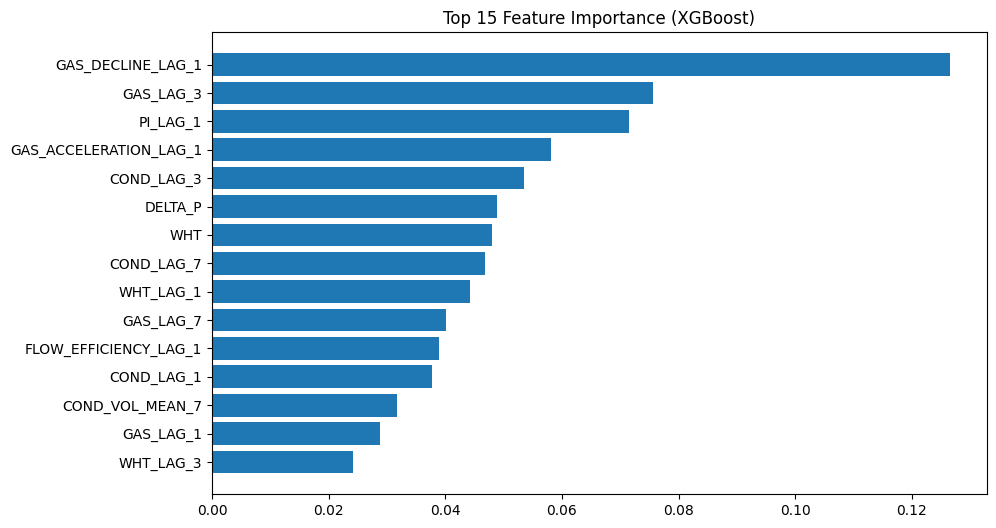

In [98]:
# ==============================
# FEATURE IMPORTANCE (XGB)
# ==============================

import matplotlib.pyplot as plt

model = xgb_model.named_steps["model"]

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop Features:")
print(feat_imp.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"][:15], feat_imp["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (XGBoost)")
plt.show()

In [99]:
feat_imp.to_csv(
    "comparison/feature_importance/hybrid_xgb_importance.csv",
    index=False
)

In [100]:
plt.savefig(
    "comparison/graphs/Hybrid_feature_importance.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [101]:
# ==============================
# R² PAR PUITS - BLIND WELLS
# ==============================

from sklearn.metrics import r2_score

# dataframe blind
df_eval = df_blind.copy()

# predictions XGB
df_eval["PRED_GAS"]   = y_blind_xgb[:, 0]
df_eval["PRED_WATER"] = y_blind_xgb[:, 1]
df_eval["PRED_COND"]  = y_blind_xgb[:, 2]

# liste résultats
results = []

# loop sur chaque puits
for well in df_eval["WELL"].unique():

    df_w = df_eval[df_eval["WELL"] == well]

    # sécurité
    if len(df_w) < 2:
        continue

    # calcul R²
    r2_gas = r2_score(df_w["W_GAS"], df_w["PRED_GAS"])
    r2_water = r2_score(df_w["WATER"], df_w["PRED_WATER"])
    r2_cond = r2_score(df_w["COND_VOL"], df_w["PRED_COND"])

    # save
    results.append({
        "WELL": well,
        "R2_GAS": r2_gas,
        "R2_WATER": r2_water,
        "R2_COND": r2_cond,
        "R2_MEAN": np.mean([r2_gas, r2_water, r2_cond])
    })

# dataframe final
df_r2_wells = pd.DataFrame(results)

# tri
df_r2_wells = df_r2_wells.sort_values(
    "R2_MEAN",
    ascending=False
)

print(df_r2_wells)

# ==============================
# STATISTIQUES GLOBALES
# ==============================

print("\n===== GLOBAL WELL PERFORMANCE =====")

print("\nMean R² GAS   :", df_r2_wells["R2_GAS"].mean())
print("Mean R² WATER :", df_r2_wells["R2_WATER"].mean())
print("Mean R² COND  :", df_r2_wells["R2_COND"].mean())

print("\nWorst wells:")
print(df_r2_wells.tail())

# ==============================
# VISUALISATION
# ==============================

plt.figure(figsize=(14,6))

plt.bar(df_r2_wells["WELL"], df_r2_wells["R2_MEAN"])

plt.xticks(rotation=90)

plt.title("Mean R² by Well - XGBoost")
plt.ylabel("R²")
plt.xlabel("Well")

plt.grid()

plt.show()

NameError: name 'y_blind_xgb' is not defined